# Module 2: Epidemic Modeling Template

## Team Members:
Vish and Christian 

## Project Title:
Mod 2 

## Project Goal:
This project seeks to

## 1. Data and disease background

Prevalence & incidence in the UVA population

- Through the data releases, we only had access to the total number of cases every day. This doesn't help with incidence but helps with prevalence of the disease. Because of this, modeling was a little harder due to the difficulty in differentiating the rate at which new cases arose vs. existing cases that were running their course. However, through different modeling methods, the trends of how the disease infected and was spread was modeled using the total cases per day numbers. 

Economic Impact
- The economical impact of the disease is very abstract, but can be explained through a couple avenues. First, medical costs, stemming from doctor's visits, prescription and OTC medications, missing part-time jobs, and much more direct impacts can cause economic loss for the university, its students, and the college town as a whole. Next, missing academic classes can have a long-term impact on the students' finances. For example, missing classes can cause a drop in grades which can affect career options. Finally, the university can be impacted through things such as decreased ticket sales during school sporting events, short-staffed dining hall employees, janitors, etc. and professors missing their obligations, negatively impacting the university as a whole. 

Symptoms

- Symptoms of the virus first included mild respiratory symptoms, sore throat, and rash which then developed into low grade fevers, rash, gastrointestinal symptoms, and joint pain. These symptoms are typical of a respiratory illness, starting in the lungs and producing airway issues, then developing into full body issues as the virus is spread throughout the body. 

Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)

- The virus is transmitted through respiratory particles. As a result, it makes first contact in a new person through the respiratory system. The infection starts there, hence why respiratory symptoms are the most prevalent and are first seen. Then, the virus spreads throughout the body through the circulatory system, causing GI symtoms, fever, rash, and joint pain. 
- The virus works in a cell and molecular sense by invading a cell through its membrane to then hijack the cell's machinery to create new viruses and reproduce. The cell is then caused to implode to release more viral particles that can go infect other cells. In a physiological spread, viruses are spread throughout the blood through the circulatory system, being pumped through the heart. For example, the viruses that started in the lungs maybe picked up into the veins, returning to the heart and being pumped to the rest of the body, increasing the rate at which more of the body is infected. 


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods

*IN A SUMMARY, DESCRIBE THE METHODS YOU USED TO ANALYZE AND MODEL THE DATA.*


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



#Plotting Data Release 1

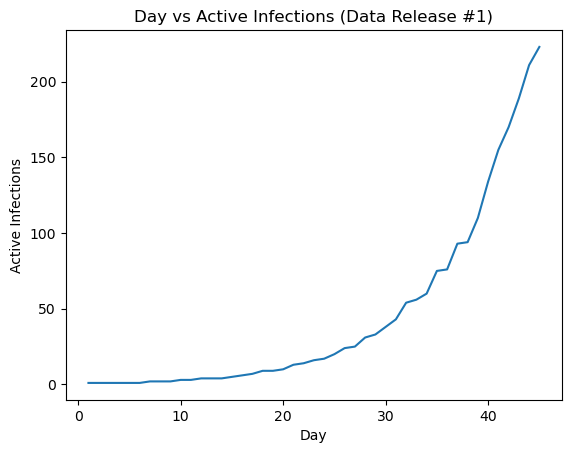

In [55]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Get current working directory (notebook's directory)
script_dir = os.getcwd()

# Build path to Data folder (go up one level to parent directory)
data_path = os.path.join(script_dir, "..", "Data",
                         "mystery_virus_daily_active_counts_RELEASE#1.csv")

data = pd.read_csv(data_path, parse_dates=['date'])

plt.figure()
plt.plot(data["day"], data["active reported daily cases"])
plt.xlabel("Day")
plt.ylabel("Active Infections")
plt.title("Day vs Active Infections (Data Release #1)")
plt.show()

Initial infection rates are increasing very slowly, picking up speed only after around 20 days. We can measure how quickly it is spreading by taking the derivative of different points on the graph. In other words, we can use what we learned about ODE's, for example, Euler's method to model how fast the graph is growing, which represents infection rate. Things such as incubation rate, probability of infection upon encounters with an infected person, and days needed for recovery from the virus helps determine the outbreak curve. 

Estimate R0 for the mystery virus data using a fit to the exponential growth in I.

Estimated growth rate r: 0.1243889313025376
Estimated R0: 1.621944656512688


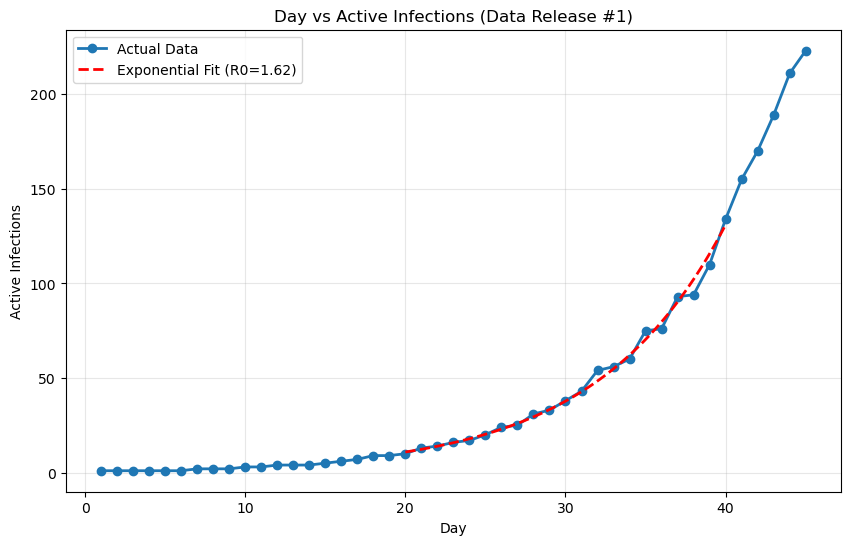

In [57]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Get current working directory (notebook's directory)
script_dir = os.getcwd()

# Build path to Data folder (go up one level to parent directory)
data_path = os.path.join(script_dir, "..", "Data",
                         "mystery_virus_daily_active_counts_RELEASE#1.csv")

data = pd.read_csv(data_path, parse_dates=['date'])

# Select exponential window for R0 calculation
exp_data = data[(data['day'] >= 20) & (data['day'] <= 40)]

log_I = np.log(exp_data['active reported daily cases'])

slope, intercept = np.polyfit(exp_data['day'], log_I, 1)

r = slope
D = 5
R0 = 1 + r * D

# Generate fitted exponential curve
fitted_days = np.linspace(20, 40, 100)
fitted_I = np.exp(intercept + slope * fitted_days)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(data["day"], data["active reported daily cases"], 'o-', label='Actual Data', linewidth=2)
plt.plot(fitted_days, fitted_I, 'r--', label=f'Exponential Fit (R0={R0:.2f})', linewidth=2)
plt.xlabel("Day")
plt.ylabel("Active Infections")
plt.title("Day vs Active Infections (Data Release #1)")
plt.legend()
plt.grid(True, alpha=0.3)

print("Estimated growth rate r:", r)
print("Estimated R0:", R0)

plt.show()

As you can see, 1.62 is a good R0 value to model the data. As a result, we think our R0 value is a very good estimate of our modeling. 

Viruses:
1. Marburg
- severe and often fatal viral hemorrhagic fever. It is caused by the Marburg virus which is related to the Ebola virus. Fatality rates are anywehere from 24% to 88% depending on level of medical care. It is transmitted through direct contact through broken skin or mucous membranes. 
2. Rabies
- Viral disease that is transmitted through rabid animal bites. The virus travels via peripheral nerves all the way to the brain. There, it causes rapid and fatal inflammation causing death. It has a short window to be cured with a vaccine due to how slowly it travels along the nerves, about 12-24 mm a day. 

#Above meets criteria material here

### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
This section should come from your python code after Data Release #1.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# figure out where the data live; __file__ only exists in a .py file
try:
    script_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:            # running inside a notebook
    script_dir = os.getcwd()

data_path = os.path.join(
    script_dir, "..", "Data",
    "mystery_virus_daily_active_counts_RELEASE#2.csv"
)
data = pd.read_csv(data_path, parse_dates=['date'])

# Build full path to CSV
data_path = os.path.join(
    script_dir,
    "..",
    "Data",
    "mystery_virus_daily_active_counts_RELEASE#2.csv"
)

data = pd.read_csv(data_path, parse_dates=['date'])

# Select exponential window
exp_data = data[(data['day'] >= 20) & (data['day'] <= 100)]

log_I = np.log(exp_data['active reported daily cases'])

slope, intercept = np.polyfit(exp_data['day'], log_I, 1)

r = slope
D = 5
R0 = 1 + r * D

print("Estimated growth rate r:", r)
print("Estimated R0:", R0)
# Implementing Euler's method for SEIR model

# Parameters (initial guesses, will be fitted later)
beta = 0.3  # infection rate
sigma = 0.2  # incubation rate (1/sigma = incubation period)
gamma = 0.1  # recovery rate (1/gamma = infectious period)

# Initial conditions (assuming total population N=10000, initial S, E, I, R)
N = 10000
S0 = N - 1
E0 = 0
I0 = 1  # start with 1 infected
R0 = 0

# Time steps
t_start = 0
t_end = 100  # days
dt = 0.1
t = np.arange(t_start, t_end, dt)

Estimated growth rate r: 0.11250566260225432
Estimated R0: 1.5625283130112715



<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
This section should come from your python code after Data Release #2.

Above expectations material here

In [ ]:
# Step 1: Function to implement Euler's method for SEIR
def euler_seir(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):
    dt = timepoints[1] - timepoints[0]  # assume uniform spacing
    S = [S0]
    E = [E0]
    I = [I0]
    R = [R0]
    for i in range(1, len(timepoints)):
        dS = -beta * S[-1] * I[-1] / N
        dE = beta * S[-1] * I[-1] / N - sigma * E[-1]
        dI = sigma * E[-1] - gamma * I[-1]
        dR = gamma * I[-1]
        
        S.append(S[-1] + dt * dS)
        E.append(E[-1] + dt * dE)
        I.append(I[-1] + dt * dI)
        R.append(R[-1] + dt * dR)
    return S, E, I, R


### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
This section should come from your python code after Data Release #2.

In [ ]:
# Step 2: Function to fit parameters using grid search
def fit_seir_parameters(timepoints, N, S0, E0, I0, R0, data):
    # Define ranges for parameters
    beta_range = np.linspace(0.1, 1.0, 10)
    sigma_range = np.linspace(0.1, 0.5, 10)
    gamma_range = np.linspace(0.05, 0.3, 10)
    
    SSE_array = []
    param_combinations = []
    
    for b in beta_range:
        for s in sigma_range:
            for g in gamma_range:
                S, E, I_sim, R = euler_seir(b, s, g, S0, E0, I0, R0, timepoints, N)
                # Interpolate I_sim to data days
                data_days = data['day'].values
                sim_I_at_data_days = np.interp(data_days, timepoints, I_sim)
                observed_I = data['active reported daily cases'].values
                SSE = np.sum((sim_I_at_data_days - observed_I)**2)
                SSE_array.append(SSE)
                param_combinations.append((b, s, g))
    
    # Find best parameters
    min_SSE_idx = np.argmin(SSE_array)
    best_beta, best_sigma, best_gamma = param_combinations[min_SSE_idx]
    best_SSE = SSE_array[min_SSE_idx]
    
    return best_beta, best_sigma, best_gamma, best_SSE

# Fit parameters
best_beta, best_sigma, best_gamma, best_SSE = fit_seir_parameters(t, N, S0, E0, I0, R0, exp_data)

print(f"Best parameters: beta={best_beta}, sigma={best_sigma}, gamma={best_gamma}, SSE={best_SSE}")

Best parameters: beta=0.5, sigma=0.1, gamma=0.07777777777777778, SSE=104620.93458660078


### 2e. Plot the model-predicted infections over time compared to the data.
This section should come from your python code after Data Release #2.

Peak infected: 2924.6613307738535
Is this reasonable? Assuming N=10000, peak at ~29.2% of population, which may be plausible for an epidemic.
Peak occurs on day: 78.9
SSE with fitted parameters: 104620.93458660078


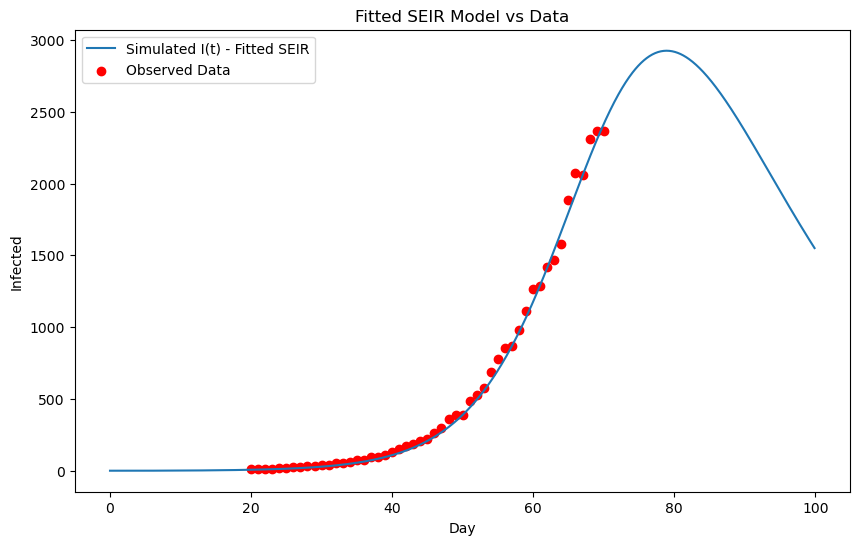

In [ ]:
# Step 3: Run the model longer to find the peak
# Extend timepoints to 200 days or until peak
t_extended = np.arange(t_start, 200, dt)
S_ext, E_ext, I_ext, R_ext = euler_seir(best_beta, best_sigma, best_gamma, S0, E0, I0, R0, t_extended, N)

# Find peak of I
peak_I = np.max(I_ext)
peak_day = t_extended[np.argmax(I_ext)]

print(f"Peak infected: {peak_I}")
print(f"Is this reasonable? Assuming N=10000, peak at ~{peak_I/N*100:.1f}% of population, which may be plausible for an epidemic.")
print(f"Peak occurs on day: {peak_day}")

# Implement Euler’s method for SEIR modeling (using fitted parameters)
# Plot Euler’s method solutions for I(t) and compare to your data
# Guess beta, sigma, and gamma and calculate SSE (now using fitted)

# Use best parameters for simulation (already done above)
S, E, I, R = euler_seir(best_beta, best_sigma, best_gamma, S0, E0, I0, R0, t, N)

# Interpolate simulated I to match data days
data_days = exp_data['day'].values
sim_I_at_data_days = np.interp(data_days, t, I)

# Calculate SSE with best parameters
observed_I = exp_data['active reported daily cases'].values
SSE = np.sum((sim_I_at_data_days - observed_I)**2)
print(f"SSE with fitted parameters: {SSE}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(t, I, label='Simulated I(t) - Fitted SEIR')
plt.scatter(exp_data['day'], exp_data['active reported daily cases'], color='red', label='Observed Data')
plt.xlabel('Day')
plt.ylabel('Infected')
plt.title('Fitted SEIR Model vs Data')
plt.legend()
plt.show()

#Used Generative AI, ChatGPT 4.0, as assistance to work through this assignment. 


### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.
This section should come from your python code after Data Release #2.


In [ ]:
It will be at around day 79 and around 2925 people infected. 

The error in the peak day was 6.02% while the error in the number of people infected on the peak day was 11%. 
Some errors in the model can be due to:
- Nuances in human interaction, such as time in the calendar year, etc. that may slow down or speed up infections slightly.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


Estimated growth rate r: 0.11250566260225432
Estimated R0: 1.5625283130112715
Best parameters: beta=0.5, sigma=0.1, gamma=0.07777777777777778, SSE=104620.93458660078
Peak infected: 2924.6613307738535
Is this reasonable? Assuming N=10000, peak at ~29.2% of population, which may be plausible for an epidemic.
Peak occurs on day: 78.9
SSE with fitted parameters: 104620.93458660078


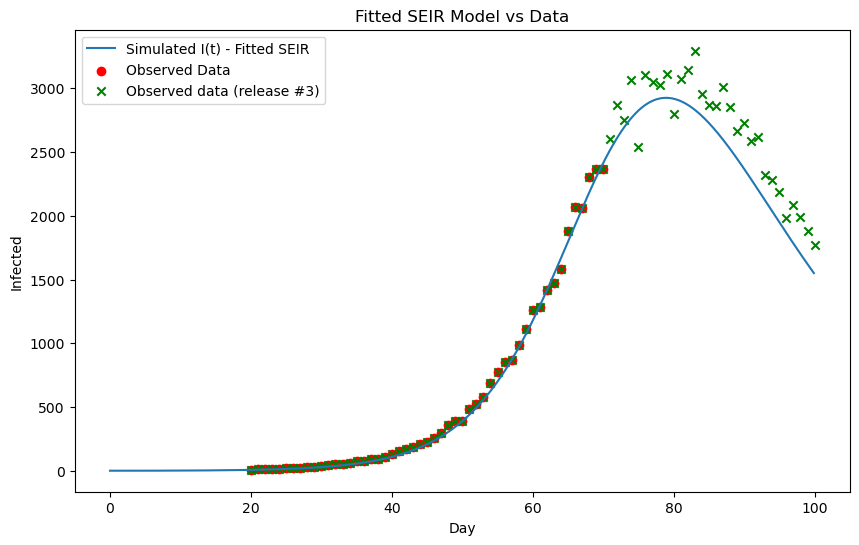

In [ ]:


# Build full path to CSV
data_path = os.path.join(
    script_dir,
    "..",
    "Data",
    "mystery_virus_daily_active_counts_RELEASE#2.csv"
)

data = pd.read_csv(data_path, parse_dates=['date'])

# Select exponential window
exp_data = data[(data['day'] >= 20) & (data['day'] <= 100)]

log_I = np.log(exp_data['active reported daily cases'])

slope, intercept = np.polyfit(exp_data['day'], log_I, 1)

r = slope
D = 5
R0 = 1 + r * D

print("Estimated growth rate r:", r)
print("Estimated R0:", R0)

# Implementing Euler's method for SEIR model

# Parameters (initial guesses, will be fitted later)
beta = 0.3  # infection rate
sigma = 0.2  # incubation rate (1/sigma = incubation period)
gamma = 0.1  # recovery rate (1/gamma = infectious period)

# Initial conditions (assuming total population N=10000, initial S, E, I, R)
N = 10000
S0 = N - 1
E0 = 0
I0 = 1  # start with 1 infected
R0 = 0

# Time steps
t_start = 0
t_end = 100  # days
dt = 0.1
t = np.arange(t_start, t_end, dt)

# Step 1: Function to implement Euler's method for SEIR
def euler_seir(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):
    dt = timepoints[1] - timepoints[0]  # assume uniform spacing
    S = [S0]
    E = [E0]
    I = [I0]
    R = [R0]
    for i in range(1, len(timepoints)):
        dS = -beta * S[-1] * I[-1] / N
        dE = beta * S[-1] * I[-1] / N - sigma * E[-1]
        dI = sigma * E[-1] - gamma * I[-1]
        dR = gamma * I[-1]
        
        S.append(S[-1] + dt * dS)
        E.append(E[-1] + dt * dE)
        I.append(I[-1] + dt * dI)
        R.append(R[-1] + dt * dR)
    return S, E, I, R

# Step 2: Function to fit parameters using grid search
def fit_seir_parameters(timepoints, N, S0, E0, I0, R0, data):
    # Define ranges for parameters
    beta_range = np.linspace(0.1, 1.0, 10)
    sigma_range = np.linspace(0.1, 0.5, 10)
    gamma_range = np.linspace(0.05, 0.3, 10)
    
    SSE_array = []
    param_combinations = []
    
    for b in beta_range:
        for s in sigma_range:
            for g in gamma_range:
                S, E, I_sim, R = euler_seir(b, s, g, S0, E0, I0, R0, timepoints, N)
                # Interpolate I_sim to data days
                data_days = data['day'].values
                sim_I_at_data_days = np.interp(data_days, timepoints, I_sim)
                observed_I = data['active reported daily cases'].values
                SSE = np.sum((sim_I_at_data_days - observed_I)**2)
                SSE_array.append(SSE)
                param_combinations.append((b, s, g))
    
    # Find best parameters
    min_SSE_idx = np.argmin(SSE_array)
    best_beta, best_sigma, best_gamma = param_combinations[min_SSE_idx]
    best_SSE = SSE_array[min_SSE_idx]
    
    return best_beta, best_sigma, best_gamma, best_SSE

# Fit parameters
best_beta, best_sigma, best_gamma, best_SSE = fit_seir_parameters(t, N, S0, E0, I0, R0, exp_data)

print(f"Best parameters: beta={best_beta}, sigma={best_sigma}, gamma={best_gamma}, SSE={best_SSE}")

# Step 3: Run the model longer to find the peak
# Extend timepoints to 200 days or until peak
t_extended = np.arange(t_start, 200, dt)
S_ext, E_ext, I_ext, R_ext = euler_seir(best_beta, best_sigma, best_gamma, S0, E0, I0, R0, t_extended, N)

# Find peak of I
peak_I = np.max(I_ext)
peak_day = t_extended[np.argmax(I_ext)]

print(f"Peak infected: {peak_I}")
print(f"Is this reasonable? Assuming N=10000, peak at ~{peak_I/N*100:.1f}% of population, which may be plausible for an epidemic.")
print(f"Peak occurs on day: {peak_day}")

# Implement Euler’s method for SEIR modeling (using fitted parameters)
# Plot Euler’s method solutions for I(t) and compare to your data
# Guess beta, sigma, and gamma and calculate SSE (now using fitted)

# Use best parameters for simulation (already done above)
S, E, I, R = euler_seir(best_beta, best_sigma, best_gamma, S0, E0, I0, R0, t, N)

# Interpolate simulated I to match data days
data_days = exp_data['day'].values
sim_I_at_data_days = np.interp(data_days, t, I)

# Calculate SSE with best parameters
observed_I = exp_data['active reported daily cases'].values
SSE = np.sum((sim_I_at_data_days - observed_I)**2)
print(f"SSE with fitted parameters: {SSE}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(t, I, label='Simulated I(t) - Fitted SEIR')
plt.scatter(exp_data['day'], exp_data['active reported daily cases'], color='red', label='Observed Data')
plt.xlabel('Day')
plt.ylabel('Infected')
plt.title('Fitted SEIR Model vs Data')
plt.legend()
# --- load release #3 and overlay on the existing plot ---------------
data3_path = os.path.join(
    script_dir,
    "..",
    "Data",
    "mystery_virus_daily_active_counts_RELEASE#3.csv"
)
data3 = pd.read_csv(data3_path, parse_dates=['date'])
exp_data3 = data3[(data3['day'] >= 20) & (data3['day'] <= 100)]

# (after you have drawn the SEIR curve and release‑#2 points:)
plt.scatter(exp_data3['day'],
            exp_data3['active reported daily cases'],
            color='green', marker='x',
            label='Observed data (release #3)')
plt.legend()          # update legend to include #3
plt.show()

### 2g. Intervention strategies for new outbreak at VT (70 days of infection)
This section should come from your python code after Data Release #3.



Baseline peak: 11114 infected on day 88.9


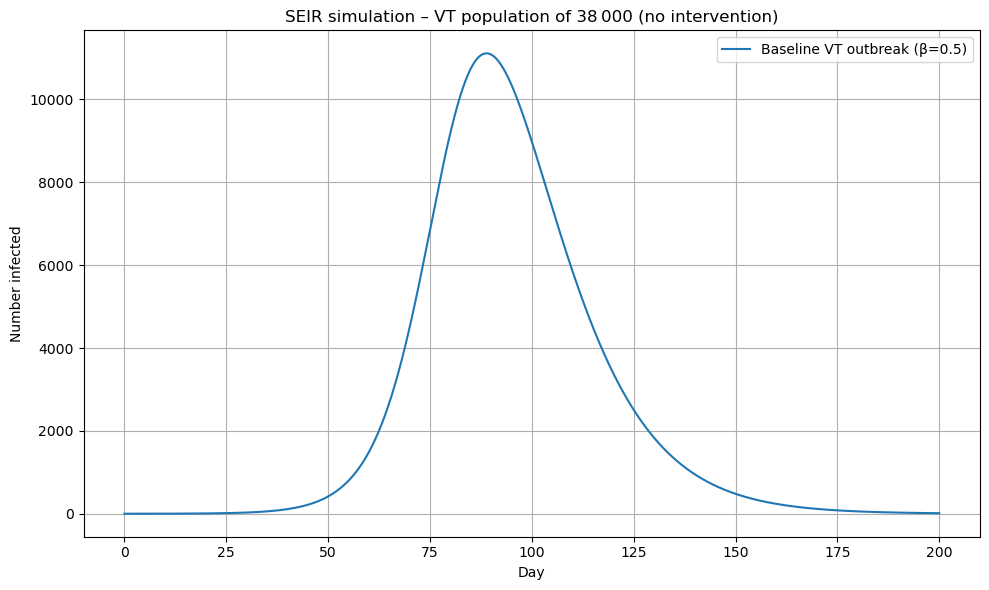

In [ ]:
#Baseline outbreak projection using best paramters of Best parameters: beta=0.5, sigma=0.1, gamma=0.07777777777777778, SSE=104620.93458660078
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# model parameters (given)
best_beta = 0.5
best_sigma = 0.1
best_gamma = 0.07777777777777778
best_SSE = 104620.93458660078           # just for reference

# initial population
S0 = 38000
E0 = 0
I0 = 1
R0 = 0
N = S0 + E0 + I0 + R0

# time grid
t_start = 0
t_end = 200      # days
dt = 0.1
t = np.arange(t_start, t_end + dt, dt)

# ----------------------------------------------------------------------
def euler_seir(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):
    """Forward‑Euler integrator for the SEIR equations."""
    dt = timepoints[1] - timepoints[0]
    S = [S0]
    E = [E0]
    I = [I0]
    R = [R0]
    for i in range(1, len(timepoints)):
        dS = -beta * S[-1] * I[-1] / N
        dE = beta * S[-1] * I[-1] / N - sigma * E[-1]
        dI = sigma * E[-1] - gamma * I[-1]
        dR = gamma * I[-1]

        S.append(S[-1] + dt * dS)
        E.append(E[-1] + dt * dE)
        I.append(I[-1] + dt * dI)
        R.append(R[-1] + dt * dR)
    return np.array(S), np.array(E), np.array(I), np.array(R)

# ----------------------------------------------------------------------
# baseline outbreak (no intervention at all)
S_base, E_base, I_base, R_base = euler_seir(
    best_beta, best_sigma, best_gamma, S0, E0, I0, R0, t, N
)
peak_I_base = I_base.max()
peak_day_base = t[np.argmax(I_base)]
print(f"Baseline peak: {peak_I_base:.0f} infected on day {peak_day_base:.1f}")

# ----------------------------------------------------------------------
# plotting the single (no‑intervention) curve
plt.figure(figsize=(10, 6))
plt.plot(t, I_base, label='Baseline VT outbreak (β=0.5)')
plt.xlabel('Day')
plt.ylabel('Number infected')
plt.title('SEIR simulation – VT population of 38 000 (no intervention)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
- Vaccination event
- Vaccination Rollout
- Mask Mandate
- School Closure

Baseline peak: 11114 infected on day 88.9
Vaccine event on day 70: 2000 vaccinated
  → 1800 protected (90%)
  → 200 unprotected (10%)
Vaccine event on day 70: 2000 vaccinated
  → 1800 protected (90%)
  → 200 unprotected (10%)
With vaccine event: 9807 infected on day 88.1


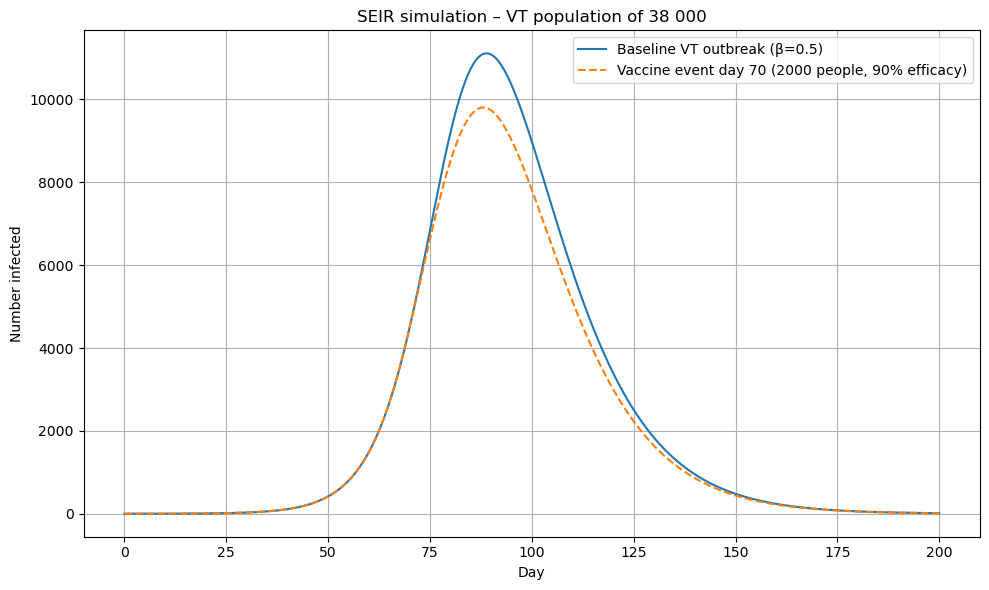

In [ ]:
#Vaccine Event
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# model parameters (given)
best_beta = 0.5
best_sigma = 0.1
best_gamma = 0.07777777777777778
best_SSE = 104620.93458660078           # provided for reference

# initial population
S0 = 38000
E0 = 0
I0 = 1
R0 = 0
N = S0 + E0 + I0 + R0

# time grid
t_start = 0
t_end = 200      # days
dt = 0.1
t = np.arange(t_start, t_end + dt, dt)

# ----------------------------------------------------------------------
def euler_seir(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):
    """Forward‑Euler integrator for the SEIR equations."""
    dt = timepoints[1] - timepoints[0]
    S = [S0]
    E = [E0]
    I = [I0]
    R = [R0]
    for i in range(1, len(timepoints)):
        dS = -beta * S[-1] * I[-1] / N
        dE = beta * S[-1] * I[-1] / N - sigma * E[-1]
        dI = sigma * E[-1] - gamma * I[-1]
        dR = gamma * I[-1]

        S.append(S[-1] + dt * dS)
        E.append(E[-1] + dt * dE)
        I.append(I[-1] + dt * dI)
        R.append(R[-1] + dt * dR)
    return np.array(S), np.array(E), np.array(I), np.array(R)

# ----------------------------------------------------------------------
# baseline outbreak (no intervention)
S_base, E_base, I_base, R_base = euler_seir(
    best_beta, best_sigma, best_gamma, S0, E0, I0, R0, t, N
)
peak_I_base = I_base.max()
peak_day_base = t[np.argmax(I_base)]
print(f"Baseline peak: {peak_I_base:.0f} infected on day {peak_day_base:.1f}")

# ----------------------------------------------------------------------
# intervention: vaccine event on day 70 (2000 people, 90% efficacy)
vaccine_day = 70
vaccine_total = 2000
vaccine_efficacy = 0.9
vaccinated_protected = vaccine_total * vaccine_efficacy
vaccinated_unprotected = vaccine_total * (1 - vaccine_efficacy)

# integrate with vaccination event
S_vax = np.zeros_like(t)
E_vax = np.zeros_like(t)
I_vax = np.zeros_like(t)
R_vax = np.zeros_like(t)
S_vax[0], E_vax[0], I_vax[0], R_vax[0] = S0, E0, I0, R0

for i in range(1, len(t)):
    # standard SEIR dynamics
    dS = -best_beta * S_vax[i-1] * I_vax[i-1] / N
    dE = best_beta * S_vax[i-1] * I_vax[i-1] / N - best_sigma * E_vax[i-1]
    dI = best_sigma * E_vax[i-1] - best_gamma * I_vax[i-1]
    dR = best_gamma * I_vax[i-1]

    S_vax[i] = S_vax[i-1] + dt * dS
    E_vax[i] = E_vax[i-1] + dt * dE
    I_vax[i] = I_vax[i-1] + dt * dI
    R_vax[i] = R_vax[i-1] + dt * dR

    # apply vaccination at the specified day
    current_day = t[i]
    if abs(current_day - vaccine_day) < dt:
        # move successfully vaccinated people to R
        S_vax[i] -= vaccine_total
        # 90% become immune
        R_vax[i] += vaccinated_protected
        # 10% stay in S
        S_vax[i] += vaccinated_unprotected
        print(f"Vaccine event on day {vaccine_day}: {vaccine_total} vaccinated")
        print(f"  → {vaccinated_protected:.0f} protected (90%)")
        print(f"  → {vaccinated_unprotected:.0f} unprotected (10%)")

peak_I_vax = I_vax.max()
peak_day_vax = t[np.argmax(I_vax)]
print(f"With vaccine event: {peak_I_vax:.0f} infected on day {peak_day_vax:.1f}")

# ----------------------------------------------------------------------
# plotting
plt.figure(figsize=(10, 6))
plt.plot(t, I_base, label='Baseline VT outbreak (β=0.5)')
plt.plot(t, I_vax, '--', label='Vaccine event day 70 (2000 people, 90% efficacy)')
plt.xlabel('Day')
plt.ylabel('Number infected')
plt.title('SEIR simulation – VT population of 38 000')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Baseline peak: 11114 infected on day 88.9
Vaccination event on day 70: 1000 people vaccinated
Vaccination event on day 70: 1000 people vaccinated
Vaccination event on day 80: 1000 people vaccinated
Vaccination event on day 80: 1000 people vaccinated
Vaccination event on day 90: 1000 people vaccinated
Vaccination event on day 90: 1000 people vaccinated
With vaccine rollout: 10020 infected on day 87.1


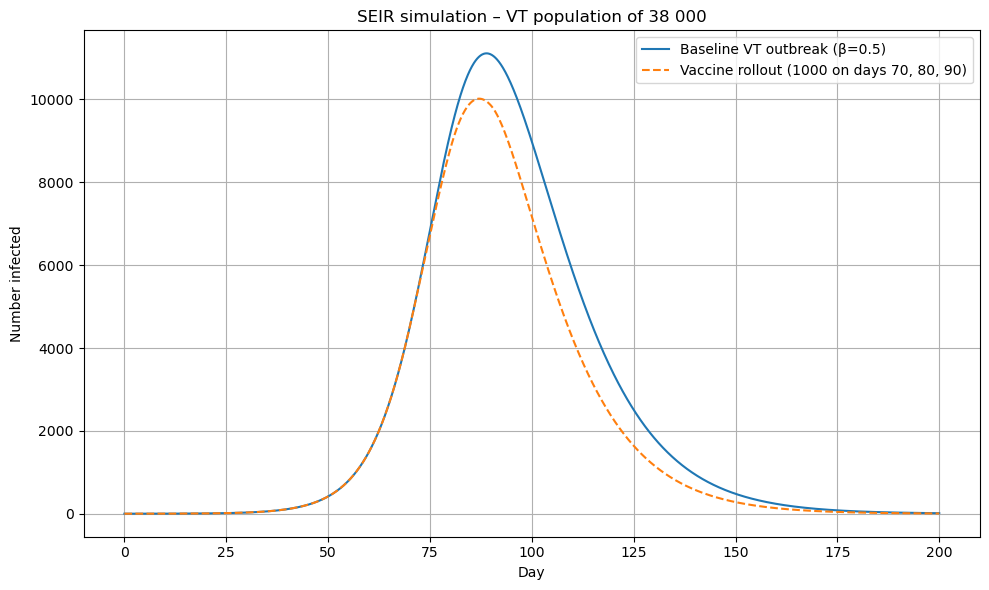

In [ ]:
#Vaccine Rollout
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# model parameters (given)
best_beta = 0.5
best_sigma = 0.1
best_gamma = 0.07777777777777778
best_SSE = 104620.93458660078           # provided for reference

# initial population
S0 = 38000
E0 = 0
I0 = 1
R0 = 0
N = S0 + E0 + I0 + R0

# time grid
t_start = 0
t_end = 200      # days
dt = 0.1
t = np.arange(t_start, t_end + dt, dt)

# ----------------------------------------------------------------------
def euler_seir(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):
    """Forward‑Euler integrator for the SEIR equations."""
    dt = timepoints[1] - timepoints[0]
    S = [S0]
    E = [E0]
    I = [I0]
    R = [R0]
    for i in range(1, len(timepoints)):
        dS = -beta * S[-1] * I[-1] / N
        dE = beta * S[-1] * I[-1] / N - sigma * E[-1]
        dI = sigma * E[-1] - gamma * I[-1]
        dR = gamma * I[-1]

        S.append(S[-1] + dt * dS)
        E.append(E[-1] + dt * dE)
        I.append(I[-1] + dt * dI)
        R.append(R[-1] + dt * dR)
    return np.array(S), np.array(E), np.array(I), np.array(R)

# ----------------------------------------------------------------------
# baseline outbreak (no intervention)
S_base, E_base, I_base, R_base = euler_seir(
    best_beta, best_sigma, best_gamma, S0, E0, I0, R0, t, N
)
peak_I_base = I_base.max()
peak_day_base = t[np.argmax(I_base)]
print(f"Baseline peak: {peak_I_base:.0f} infected on day {peak_day_base:.1f}")

# ----------------------------------------------------------------------
# intervention: vaccination rollout (1000 people on days 70, 80, 90)
vaccine_days = [70, 80, 90]
vaccine_per_day = 1000

# integrate with vaccination events
S_vax = np.zeros_like(t)
E_vax = np.zeros_like(t)
I_vax = np.zeros_like(t)
R_vax = np.zeros_like(t)
S_vax[0], E_vax[0], I_vax[0], R_vax[0] = S0, E0, I0, R0

for i in range(1, len(t)):
    # standard SEIR dynamics
    dS = -best_beta * S_vax[i-1] * I_vax[i-1] / N
    dE = best_beta * S_vax[i-1] * I_vax[i-1] / N - best_sigma * E_vax[i-1]
    dI = best_sigma * E_vax[i-1] - best_gamma * I_vax[i-1]
    dR = best_gamma * I_vax[i-1]

    S_vax[i] = S_vax[i-1] + dt * dS
    E_vax[i] = E_vax[i-1] + dt * dE
    I_vax[i] = I_vax[i-1] + dt * dI
    R_vax[i] = R_vax[i-1] + dt * dR

    # apply vaccination at specified days (find closest index)
    current_day = t[i]
    for vax_day in vaccine_days:
        # check if we just crossed a vaccination day (within one time step)
        if abs(current_day - vax_day) < dt:
            # move vaccinated people from S to R
            S_vax[i] -= vaccine_per_day
            R_vax[i] += vaccine_per_day
            print(f"Vaccination event on day {vax_day}: {vaccine_per_day} people vaccinated")

peak_I_vax = I_vax.max()
peak_day_vax = t[np.argmax(I_vax)]
print(f"With vaccine rollout: {peak_I_vax:.0f} infected on day {peak_day_vax:.1f}")

# ----------------------------------------------------------------------
# plotting
plt.figure(figsize=(10, 6))
plt.plot(t, I_base, label='Baseline VT outbreak (β=0.5)')
plt.plot(t, I_vax, '--', label='Vaccine rollout (1000 on days 70, 80, 90)')
plt.xlabel('Day')
plt.ylabel('Number infected')
plt.title('SEIR simulation – VT population of 38 000')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Baseline peak: 11114 infected on day 88.9
With mask mandate: 9140 infected on day 90.7


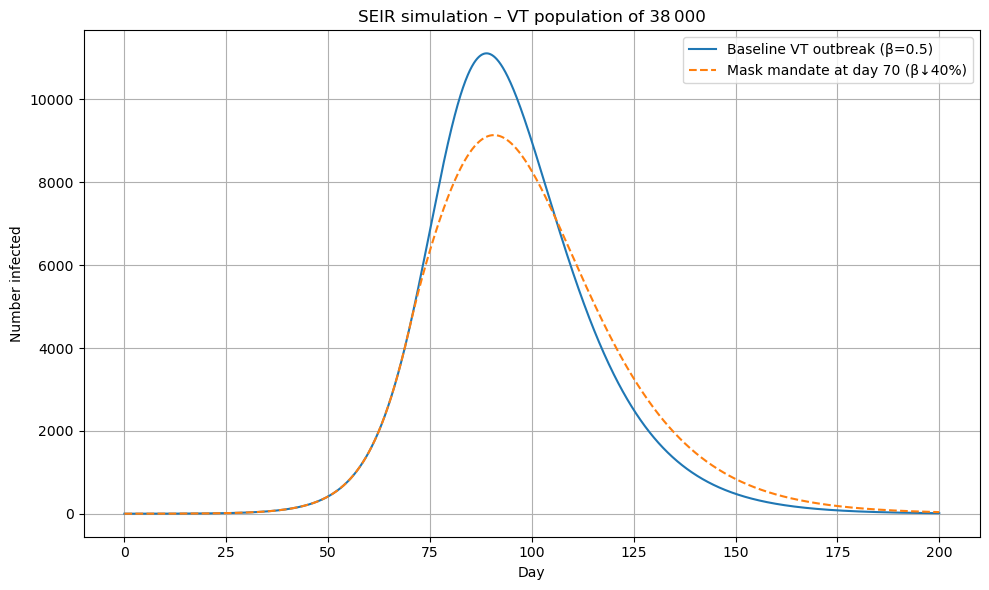

In [ ]:
#Mask Mandate
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# model parameters (given)
best_beta = 0.5
best_sigma = 0.1
best_gamma = 0.07777777777777778
best_SSE = 104620.93458660078           # provided for reference

# initial population
S0 = 38000
E0 = 0
I0 = 1
R0 = 0
N = S0 + E0 + I0 + R0

# time grid
t_start = 0
t_end = 200      # days
dt = 0.1
t = np.arange(t_start, t_end + dt, dt)

# ----------------------------------------------------------------------
def euler_seir(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):
    """Forward‐Euler integrator for the SEIR equations."""
    dt = timepoints[1] - timepoints[0]
    S = [S0]
    E = [E0]
    I = [I0]
    R = [R0]
    for i in range(1, len(timepoints)):
        dS = -beta * S[-1] * I[-1] / N
        dE = beta * S[-1] * I[-1] / N - sigma * E[-1]
        dI = sigma * E[-1] - gamma * I[-1]
        dR = gamma * I[-1]

        S.append(S[-1] + dt * dS)
        E.append(E[-1] + dt * dE)
        I.append(I[-1] + dt * dI)
        R.append(R[-1] + dt * dR)
    return np.array(S), np.array(E), np.array(I), np.array(R)

# ----------------------------------------------------------------------
# baseline outbreak (no intervention)
S_base, E_base, I_base, R_base = euler_seir(
    best_beta, best_sigma, best_gamma, S0, E0, I0, R0, t, N
)
peak_I_base = I_base.max()
peak_day_base = t[np.argmax(I_base)]
print(f"Baseline peak: {peak_I_base:.0f} infected on day {peak_day_base:.1f}")

# ----------------------------------------------------------------------
# intervention: mask mandate at day 70, β reduced 40 %
mask_day = 70
reduction = 0.4                    # fraction by which β is cut
beta_profile = np.ones_like(t) * best_beta
beta_profile[t >= mask_day] *= (1 - reduction)

# integrate with time‑varying β
S_mask = np.zeros_like(t)
E_mask = np.zeros_like(t)
I_mask = np.zeros_like(t)
R_mask = np.zeros_like(t)
S_mask[0], E_mask[0], I_mask[0], R_mask[0] = S0, E0, I0, R0

for i in range(1, len(t)):
    b = beta_profile[i-1]
    dS = -b * S_mask[i-1] * I_mask[i-1] / N
    dE = b * S_mask[i-1] * I_mask[i-1] / N - best_sigma * E_mask[i-1]
    dI = best_sigma * E_mask[i-1] - best_gamma * I_mask[i-1]
    dR = best_gamma * I_mask[i-1]
    S_mask[i] = S_mask[i-1] + dt * dS
    E_mask[i] = E_mask[i-1] + dt * dE
    I_mask[i] = I_mask[i-1] + dt * dI
    R_mask[i] = R_mask[i-1] + dt * dR

peak_I_mask = I_mask.max()
peak_day_mask = t[np.argmax(I_mask)]
print(f"With mask mandate: {peak_I_mask:.0f} infected on day {peak_day_mask:.1f}")

# ----------------------------------------------------------------------
# plotting
plt.figure(figsize=(10, 6))
plt.plot(t, I_base, label='Baseline VT outbreak (β=0.5)')
plt.plot(t, I_mask, '--', label='Mask mandate at day 70 (β↓40%)')
plt.xlabel('Day')
plt.ylabel('Number infected')
plt.title('SEIR simulation – VT population of 38 000')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Baseline peak: 11114 infected on day 88.9
With school closure: 8602 infected on day 101.4


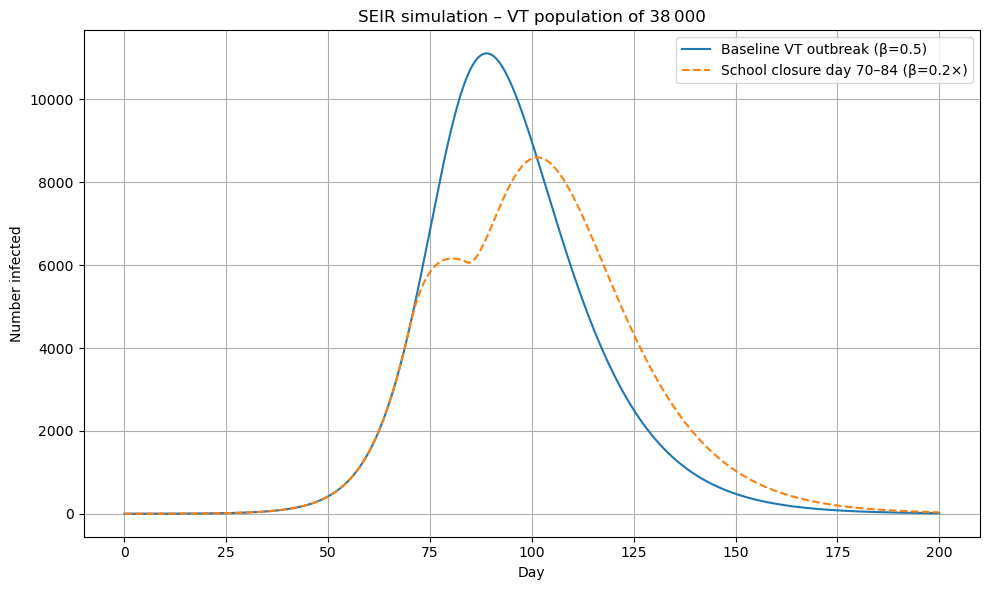

In [ ]:
#School Closures
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# model parameters (given)
best_beta = 0.5
best_sigma = 0.1
best_gamma = 0.07777777777777778
best_SSE = 104620.93458660078           # provided for reference

# initial population
S0 = 38000
E0 = 0
I0 = 1
R0 = 0
N = S0 + E0 + I0 + R0

# time grid
t_start = 0
t_end = 200      # days
dt = 0.1
t = np.arange(t_start, t_end + dt, dt)

# ----------------------------------------------------------------------
def euler_seir(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):
    """Forward‑Euler integrator for the SEIR equations."""
    dt = timepoints[1] - timepoints[0]
    S = [S0]
    E = [E0]
    I = [I0]
    R = [R0]
    for i in range(1, len(timepoints)):
        dS = -beta * S[-1] * I[-1] / N
        dE = beta * S[-1] * I[-1] / N - sigma * E[-1]
        dI = sigma * E[-1] - gamma * I[-1]
        dR = gamma * I[-1]

        S.append(S[-1] + dt * dS)
        E.append(E[-1] + dt * dE)
        I.append(I[-1] + dt * dI)
        R.append(R[-1] + dt * dR)
    return np.array(S), np.array(E), np.array(I), np.array(R)

# ----------------------------------------------------------------------
# baseline outbreak (no intervention)
S_base, E_base, I_base, R_base = euler_seir(
    best_beta, best_sigma, best_gamma, S0, E0, I0, R0, t, N
)
peak_I_base = I_base.max()
peak_day_base = t[np.argmax(I_base)]
print(f"Baseline peak: {peak_I_base:.0f} infected on day {peak_day_base:.1f}")

# ----------------------------------------------------------------------
# intervention: 14‑day school closure starting day 70
closure_start = 70
closure_end   = closure_start + 14   # day 84

# build β profile: normal before/after, 20% during closure
beta_profile = np.ones_like(t) * best_beta
mask = (t >= closure_start) & (t < closure_end)
beta_profile[mask] *= 0.2   # only 20% of normal contacts

# integrate with time‑varying β
S_close = np.zeros_like(t)
E_close = np.zeros_like(t)
I_close = np.zeros_like(t)
R_close = np.zeros_like(t)
S_close[0], E_close[0], I_close[0], R_close[0] = S0, E0, I0, R0

for i in range(1, len(t)):
    b = beta_profile[i-1]
    dS = -b * S_close[i-1] * I_close[i-1] / N
    dE = b * S_close[i-1] * I_close[i-1] / N - best_sigma * E_close[i-1]
    dI = best_sigma * E_close[i-1] - best_gamma * I_close[i-1]
    dR = best_gamma * I_close[i-1]
    S_close[i] = S_close[i-1] + dt * dS
    E_close[i] = E_close[i-1] + dt * dE
    I_close[i] = I_close[i-1] + dt * dI
    R_close[i] = R_close[i-1] + dt * dR

peak_I_close = I_close.max()
peak_day_close = t[np.argmax(I_close)]
print(f"With school closure: {peak_I_close:.0f} infected on day {peak_day_close:.1f}")

# ----------------------------------------------------------------------
# plotting
plt.figure(figsize=(10, 6))
plt.plot(t, I_base, label='Baseline VT outbreak (β=0.5)')
plt.plot(t, I_close, '--', label='School closure day 70–84 (β=0.2×)')
plt.xlabel('Day')
plt.ylabel('Number infected')
plt.title('SEIR simulation – VT population of 38 000')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Baseline peak: 11114 infected on day 88.9
With school closure: 8602 infected on day 101.4


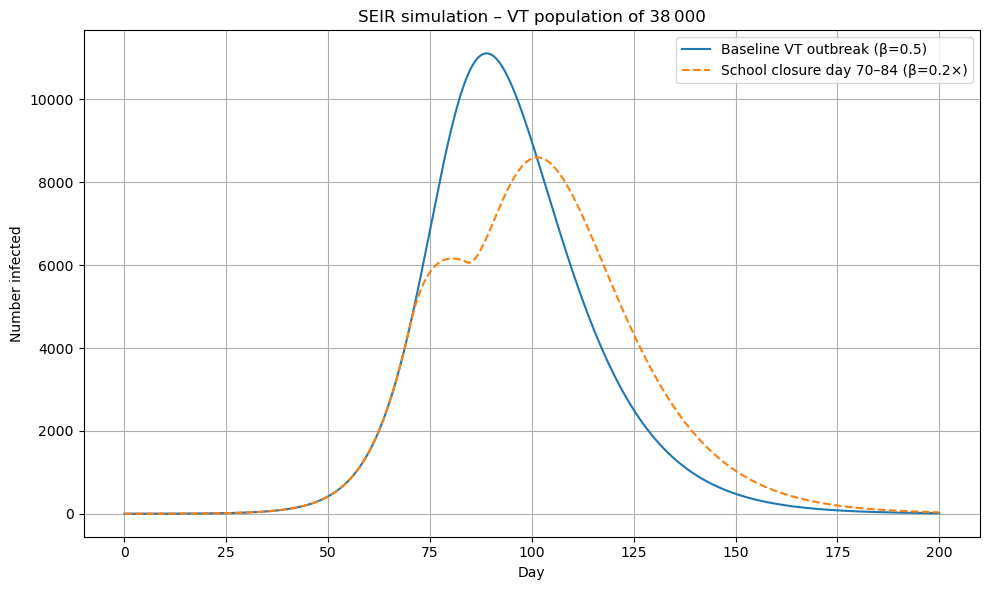

In [ ]:
#School Closures vs. Mask Mandate
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# model parameters (given)
best_beta = 0.5
best_sigma = 0.1
best_gamma = 0.07777777777777778
best_SSE = 104620.93458660078           # provided for reference

# initial population
S0 = 38000
E0 = 0
I0 = 1
R0 = 0
N = S0 + E0 + I0 + R0

# time grid
t_start = 0
t_end = 200      # days
dt = 0.1
t = np.arange(t_start, t_end + dt, dt)

# ----------------------------------------------------------------------
def euler_seir(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):
    """Forward‑Euler integrator for the SEIR equations."""
    dt = timepoints[1] - timepoints[0]
    S = [S0]
    E = [E0]
    I = [I0]
    R = [R0]
    for i in range(1, len(timepoints)):
        dS = -beta * S[-1] * I[-1] / N
        dE = beta * S[-1] * I[-1] / N - sigma * E[-1]
        dI = sigma * E[-1] - gamma * I[-1]
        dR = gamma * I[-1]

        S.append(S[-1] + dt * dS)
        E.append(E[-1] + dt * dE)
        I.append(I[-1] + dt * dI)
        R.append(R[-1] + dt * dR)
    return np.array(S), np.array(E), np.array(I), np.array(R)

# ----------------------------------------------------------------------
# baseline outbreak (no intervention)
S_base, E_base, I_base, R_base = euler_seir(
    best_beta, best_sigma, best_gamma, S0, E0, I0, R0, t, N
)
peak_I_base = I_base.max()
peak_day_base = t[np.argmax(I_base)]
print(f"Baseline peak: {peak_I_base:.0f} infected on day {peak_day_base:.1f}")

# ----------------------------------------------------------------------
# intervention: 14‑day school closure starting day 70
closure_start = 70
closure_end   = closure_start + 14   # day 84

# build β profile: normal before/after, 20% during closure
beta_profile = np.ones_like(t) * best_beta
mask = (t >= closure_start) & (t < closure_end)
beta_profile[mask] *= 0.2   # only 20% of normal contacts

# integrate with time‑varying β
S_close = np.zeros_like(t)
E_close = np.zeros_like(t)
I_close = np.zeros_like(t)
R_close = np.zeros_like(t)
S_close[0], E_close[0], I_close[0], R_close[0] = S0, E0, I0, R0

for i in range(1, len(t)):
    b = beta_profile[i-1]
    dS = -b * S_close[i-1] * I_close[i-1] / N
    dE = b * S_close[i-1] * I_close[i-1] / N - best_sigma * E_close[i-1]
    dI = best_sigma * E_close[i-1] - best_gamma * I_close[i-1]
    dR = best_gamma * I_close[i-1]
    S_close[i] = S_close[i-1] + dt * dS
    E_close[i] = E_close[i-1] + dt * dE
    I_close[i] = I_close[i-1] + dt * dI
    R_close[i] = R_close[i-1] + dt * dR

peak_I_close = I_close.max()
peak_day_close = t[np.argmax(I_close)]
print(f"With school closure: {peak_I_close:.0f} infected on day {peak_day_close:.1f}")

# ----------------------------------------------------------------------
# plotting
plt.figure(figsize=(10, 6))
plt.plot(t, I_base, label='Baseline VT outbreak (β=0.5)')
plt.plot(t, I_close, '--', label='School closure day 70–84 (β=0.2×)')
plt.xlabel('Day')
plt.ylabel('Number infected')
plt.title('SEIR simulation – VT population of 38 000')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

Cite AI USE here.